## Reinforcement Learning Environment / Jesús Andrés García-Casarrubios González

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import yfinance as yf
import gymnasium as gym

from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

FILE_PATH = "Binance_BTCUSDT_1h.csv"

def load_data(path):

    df = pd.read_csv(path, skiprows=1)

    df.columns = df.columns.str.strip()

    df = df.rename(columns={
        "Volume BTC": "Volume_BTC",
        "Volume USDT": "Volume_USDT"
    })

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df = df.dropna(subset=["Date"])

    df = df.sort_values("Date").reset_index(drop=True)

    numeric_cols = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume_BTC",
        "Volume_USDT",
        "tradecount"
    ]

    df[numeric_cols] = df[numeric_cols].astype(float)

    return df


# Reacomodar a 4 Horas
def resample_4h(df):

    df = df.set_index("Date")

    df = df.resample("4h").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "Volume_BTC": "sum",
        "Volume_USDT": "sum",
        "tradecount": "sum"
    })

    df = df.dropna().reset_index()

    return df

# Features
def create_features(df):

    df["ret_1h"] = np.log(df["Close"] / df["Close"].shift(1))

    df["ret_24h"] = np.log(df["Close"] / df["Close"].shift(24))

    df["sma_24"] = df["Close"].rolling(24).mean()
    df["sma_168"] = df["Close"].rolling(168).mean()

    df["dist_sma24"] = (
        (df["Close"] - df["sma_24"]) / df["sma_24"]
    )

    df["dist_sma168"] = (
        (df["Close"] - df["sma_168"]) / df["sma_168"]
    )

    df["vol_24"] = df["ret_1h"].rolling(24).std()
    df["vol_168"] = df["ret_1h"].rolling(168).std()

    df["hl_range"] = (
        (df["High"] - df["Low"]) / df["Close"]
    )

    df["vol_usdt_z"] = (
        (df["Volume_USDT"] - df["Volume_USDT"].rolling(168).mean())
        / df["Volume_USDT"].rolling(168).std()
    )

    df["tradecount_z"] = (
        (df["tradecount"] - df["tradecount"].rolling(168).mean())
        / df["tradecount"].rolling(168).std()
    )

    df = df.dropna().reset_index(drop=True)

    return df

# Environment
class BTCTradingEnv(gym.Env):

    def __init__(
        self,
        df,
        initial_capital=10000,
        fee=0.00125,
        max_holding=8
    ):

        super().__init__()

        self.df = df.reset_index(drop=True)

        self.initial_capital = initial_capital
        self.fee = fee
        self.max_holding = max_holding

        self.features = [
            "ret_1h",
            "ret_24h",
            "dist_sma24",
            "dist_sma168",
            "vol_24",
            "vol_168",
            "hl_range",
            "vol_usdt_z",
            "tradecount_z"
        ]

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.features),),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):

        self.current_step = 0
        self.capital = self.initial_capital
        self.done = False
        self.trade_log = []

        return self._get_obs(), {}

    def _get_obs(self):

        idx = min(
            self.current_step,
            len(self.df) - 1
        )

        return self.df.iloc[idx][self.features].values.astype(np.float32)

    def step(self, action):

        if self.done:
            return self._get_obs(), 0, True, False, {}

        if action == 0:

            reward = -0.0001
            self.current_step += 1

        else:

            side = 1 if action == 1 else -1

            reward, trade = self._trade(side)

            self.trade_log.append(trade)

        if self.current_step >= len(self.df) - 1:
            self.done = True

        return self._get_obs(), reward, self.done, False, {}

    def _trade(self, side):

        entry_idx = self.current_step

        if entry_idx >= len(self.df) - 1:

            return 0, {
                "net": 0
            }

        entry_price = self.df.iloc[entry_idx]["Close"]

        exit_idx = min(
            entry_idx + self.max_holding,
            len(self.df) - 1
        )

        exit_price = self.df.iloc[exit_idx]["Close"]

        gross = (
            side *
            (exit_price - entry_price)
            / entry_price
        )

        costs = 2 * self.fee

        net = gross - costs

        self.capital *= (1 + net)

        reward = net * 10

        trade = {
            "entry_timestamp": self.df.iloc[entry_idx]["Date"],
            "exit_timestamp": self.df.iloc[exit_idx]["Date"],
            "entry_price": entry_price,
            "exit_price": exit_price,
            "side": side,
            "gross_pnl": gross,
            "costs": costs,
            "net": net
        }

        self.current_step = exit_idx + 1

        return reward, trade

# DATA
df = load_data(FILE_PATH)

df = resample_4h(df)

df = create_features(df)

# SP500
spy = yf.download(
    "SPY",
    start="2017-08-17",
    end="2026-04-26"
)

spy = spy.reset_index()

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

price_col = (
    "Adj Close"
    if "Adj Close" in spy.columns
    else "Close"
)


# Folds
folds = {
    1: {
        "train": ("2017-08-17","2021-12-31"),
        "test": ("2023-01-01","2023-12-31")
    },

    2: {
        "train": ("2017-08-17","2022-12-31"),
        "test": ("2024-01-01","2024-12-31")
    },

    3: {
        "train": ("2017-08-17","2023-12-31"),
        "test": ("2025-01-01","2025-12-31")
    },

    4: {
        "train": ("2017-08-17","2024-12-31"),
        "test": ("2026-01-01","2026-04-26")
    }
}


# Resultados

results = []


# Loops

for fold_id, cfg in folds.items():

    print(f"\n===== FOLD {fold_id} =====")

    train_df = df[
        (df["Date"] >= cfg["train"][0]) &
        (df["Date"] <= cfg["train"][1])
    ].reset_index(drop=True)

    test_df = df[
        (df["Date"] >= cfg["test"][0]) &
        (df["Date"] <= cfg["test"][1])
    ].reset_index(drop=True)

    print("Train size:", len(train_df))
    print("Test size:", len(test_df))


    # Análisis del Feature
    feature_cols = [
        "ret_1h",
        "ret_24h",
        "dist_sma24",
        "dist_sma168",
        "vol_24",
        "vol_168",
        "hl_range",
        "vol_usdt_z",
        "tradecount_z"
    ]

    feature_corrs = []

    future_return = train_df["Close"].pct_change().shift(-1)

    for col in feature_cols:

        corr = train_df[col].corr(future_return)

        feature_corrs.append({
            "feature": col,
            "correlation_future_return": corr
        })

    feature_df = pd.DataFrame(feature_corrs)

    feature_df.to_csv(
        f"feature_analysis_fold_{fold_id}.csv",
        index=False
    )

    # Train
    train_env = Monitor(BTCTradingEnv(train_df))

    model = PPO(
        "MlpPolicy",
        train_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        gamma=0.99,
        ent_coef=0.1,
        seed=SEED,
        verbose=0
    )

    model.learn(total_timesteps=20000)

    # Curva de Aprendizaje
    rewards = train_env.get_episode_rewards()

    plt.figure(figsize=(10,5))
    plt.plot(rewards)
    plt.title(f"Training Curve Fold {fold_id}")
    plt.xlabel("Episode")
    plt.ylabel("Reward")

    plt.savefig(
        f"training_curves_fold_{fold_id}.png"
    )

    plt
    # Test
    test_env = BTCTradingEnv(test_df)

    obs, _ = test_env.reset()

    done = False

    equity = []

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, _, done, _, _ = test_env.step(action)

        equity.append(test_env.capital)

    # Trades
    df_trades = pd.DataFrame(test_env.trade_log)

    df_trades.to_csv(
        f"trade_log_fold_{fold_id}.csv",
        index=False
    )

    print("Trades:", len(df_trades))

    # Returns
    if len(df_trades) > 0:

        rl_return = (
            (df_trades["net"] + 1).prod()
            - 1
        )

    else:

        rl_return = 0

    # Btc Hold
    btc_hold = (
        test_df["Close"].iloc[-1]
        / test_df["Close"].iloc[0]
        - 1
    )

    # SP500
    spy_test = spy[
        (spy["Date"] >= cfg["test"][0]) &
        (spy["Date"] <= cfg["test"][1])
    ]

    sp500 = (
        spy_test[price_col].iloc[-1]
        / spy_test[price_col].iloc[0]
        - 1
    )

    sp500 = float(sp500)

    # SHARPE
    equity_series = pd.Series(equity)

    returns = equity_series.pct_change().dropna()

    if len(returns) > 1 and returns.std() != 0:

        sharpe = (
            returns.mean()
            / returns.std()
        ) * np.sqrt(365)

    else:

        sharpe = 0

    # Max Drawdown
    running_max = equity_series.cummax()

    drawdown = (
        equity_series - running_max
    ) / running_max

    max_dd = drawdown.min()

    # Equity Curve
    plt.figure(figsize=(10,5))

    plt.plot(
        equity_series.values,
        label="RL Strategy"
    )

    plt.title(f"Equity Curve Fold {fold_id}")

    plt.legend()

    plt.savefig(
        f"equity_curves_test_fold_{fold_id}.png"
    )

    plt.close()

    # Validar Resultados CSV
    validation_df = pd.DataFrame([{
        "learning_rate": 3e-4,
        "gamma": 0.99,
        "ent_coef": 0.1,
        "timesteps": 20000,
        "rl_return": rl_return
    }])

    validation_df.to_csv(
        f"validation_results_fold_{fold_id}.csv",
        index=False
    )


    results.append({

        "fold": fold_id,

        "rl_return": rl_return,

        "btc_hold": btc_hold,

        "sp500": sp500,

        "sharpe": sharpe,

        "max_dd": max_dd,

        "trades": len(df_trades)
    })

# Resumen Métricas
results_df = pd.DataFrame(results)

results_df.to_csv(
    "metrics_summary.csv",
    index=False
)

print("\n===== RESULTADOS =====")
print(results_df)

print("\n===== PROMEDIOS =====")
print(results_df.mean(numeric_only=True))

[*********************100%***********************]  1 of 1 completed



===== FOLD 1 =====
Train size: 9236
Test size: 2185
Trades: 26

===== FOLD 2 =====
Train size: 11426
Test size: 2191
Trades: 196

===== FOLD 3 =====
Train size: 13616
Test size: 2075
Trades: 230

===== FOLD 4 =====
Train size: 15812
Test size: 643
Trades: 67

===== RESULTADOS =====
   fold  rl_return  btc_hold     sp500    sharpe    max_dd  trades
0     1  -0.395975  1.551013  0.267092 -0.901282 -0.396734      26
1     2  -0.093893  1.185413  0.255893 -0.111456 -0.461984     196
2     3  -0.644814 -0.057386  0.180090 -3.193636 -0.685942     230
3     4  -0.224321 -0.118910  0.047894 -1.619483 -0.295296      67

===== PROMEDIOS =====
fold           2.500000
rl_return     -0.339751
btc_hold       0.640032
sp500          0.187742
sharpe        -1.456464
max_dd        -0.459989
trades       129.750000
dtype: float64


In [2]:
import pandas as pd
import numpy as np
import random
import torch
import yfinance as yf

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym
from gymnasium import spaces

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

FILE_PATH = "Binance_BTCUSDT_1h.csv"

In [3]:
def load_data(path):
    df = pd.read_csv(path, skiprows=1)
    df.columns = df.columns.str.strip()

    df = df.rename(columns={
        "Volume BTC": "Volume_BTC",
        "Volume USDT": "Volume_USDT"
    })

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    numeric_cols = ["Open","High","Low","Close","Volume_BTC","Volume_USDT","tradecount"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    return df

In [4]:
def resample_4h(df):
    df = df.set_index("Date")
    df = df.resample("4h").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "Volume_BTC": "sum",
        "Volume_USDT": "sum",
        "tradecount": "sum"
    }).dropna().reset_index()
    return df


def create_features(df):

    df["ret_1h"] = np.log(df["Close"] / df["Close"].shift(1))
    df["ret_24h"] = np.log(df["Close"] / df["Close"].shift(24))

    df["sma_24"] = df["Close"].rolling(24).mean()
    df["sma_168"] = df["Close"].rolling(168).mean()

    df["dist_sma24"] = (df["Close"] - df["sma_24"]) / df["sma_24"]
    df["dist_sma168"] = (df["Close"] - df["sma_168"]) / df["sma_168"]

    df["vol_24"] = df["ret_1h"].rolling(24).std()
    df["vol_168"] = df["ret_1h"].rolling(168).std()

    df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]

    df["vol_usdt_z"] = (
        (df["Volume_USDT"] - df["Volume_USDT"].rolling(168).mean())
        / df["Volume_USDT"].rolling(168).std()
    )

    df["tradecount_z"] = (
        (df["tradecount"] - df["tradecount"].rolling(168).mean())
        / df["tradecount"].rolling(168).std()
    )

    df = df.dropna().reset_index(drop=True)

    return df

In [5]:
class BTCTradingEnv(gym.Env):

    def __init__(self, df, initial_capital=10000, fee=0.00125, max_holding=8):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.initial_capital = initial_capital
        self.fee = fee
        self.max_holding = max_holding

        self.features = [
            "ret_1h","ret_24h",
            "dist_sma24","dist_sma168",
            "vol_24","vol_168",
            "hl_range",
            "vol_usdt_z",
            "tradecount_z"
        ]

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.features),),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        self.current_step = 0
        self.capital = self.initial_capital
        self.done = False
        self.trade_log = []
        return self._get_obs(), {}

    def _get_obs(self):
        idx = min(self.current_step, len(self.df) - 1)
        return self.df.iloc[idx][self.features].values.astype(np.float32)

    def step(self, action):

        if self.done:
            return self._get_obs(), 0, True, False, {}

        if action == 0:
            reward = -0.00001 * self.current_step
            self.current_step += 1
        else:
            side = 1 if action == 1 else -1
            reward, trade = self._trade(side)
            self.trade_log.append(trade)

        if self.current_step >= len(self.df) - 1:
            self.done = True

        return self._get_obs(), reward, self.done, False, {}

    def _trade(self, side):

        entry = self.current_step

        if entry >= len(self.df) - 1:
            return 0, {"net": 0}

        entry_price = self.df.iloc[entry]["Close"]

        exit_idx = min(entry + self.max_holding, len(self.df) - 1)
        exit_price = self.df.iloc[exit_idx]["Close"]

        net = side * (exit_price - entry_price) / entry_price - 2*self.fee
        self.capital *= (1 + net)

        reward = net * 10

        self.current_step = exit_idx + 1

        return reward, {"net": net}

In [6]:
df = load_data(FILE_PATH)
df = resample_4h(df)
df = create_features(df)

# SP500
spy = yf.download("SPY", start="2017-08-17", end="2026-04-26")
spy = spy.reset_index()
price_col = "Adj Close" if "Adj Close" in spy.columns else "Close"

folds = {
    1: {"train": ("2017","2021"), "test": ("2023","2023")},
    2: {"train": ("2017","2022"), "test": ("2024","2024")},
    3: {"train": ("2017","2023"), "test": ("2025","2025")},
    4: {"train": ("2017","2024"), "test": ("2026","2026")}
}

results = []

for fold_id, cfg in folds.items():

    print(f"\nFOLD {fold_id}")

    train_df = df[(df["Date"] >= cfg["train"][0]) & (df["Date"] <= cfg["train"][1])]
    test_df = df[(df["Date"] >= cfg["test"][0]) & (df["Date"] <= cfg["test"][1])]

    train_env = Monitor(BTCTradingEnv(train_df))

    model = PPO("MlpPolicy", train_env, verbose=0)
    model.learn(total_timesteps=100000)

    test_env = BTCTradingEnv(test_df)
    obs,_ = test_env.reset()

    equity = []
    done = False

    while not done:
        action,_ = model.predict(obs)
        obs,_,done,_,_ = test_env.step(action)
        equity.append(test_env.capital)

    df_trades = pd.DataFrame(test_env.trade_log)

    rl_return = (df_trades["net"]+1).prod()-1 if len(df_trades)>0 else 0

    btc_hold = test_df["Close"].iloc[-1]/test_df["Close"].iloc[0]-1 if len(test_df)>1 else 0

    spy_test = spy[(spy["Date"]>=cfg["test"][0])&(spy["Date"]<=cfg["test"][1])]
    sp500 = spy_test[price_col].iloc[-1]/spy_test[price_col].iloc[0]-1 if len(spy_test)>1 else 0

    results.append({
        "fold": fold_id,
        "rl_return": rl_return,
        "btc_hold": btc_hold,
        "sp500": sp500
    })

results_df = pd.DataFrame(results)
print(results_df)

[*********************100%***********************]  1 of 1 completed



FOLD 1

FOLD 2

FOLD 3

FOLD 4
   fold  rl_return  btc_hold  sp500
0     1          0         0      0
1     2          0         0      0
2     3          0         0      0
3     4          0         0      0


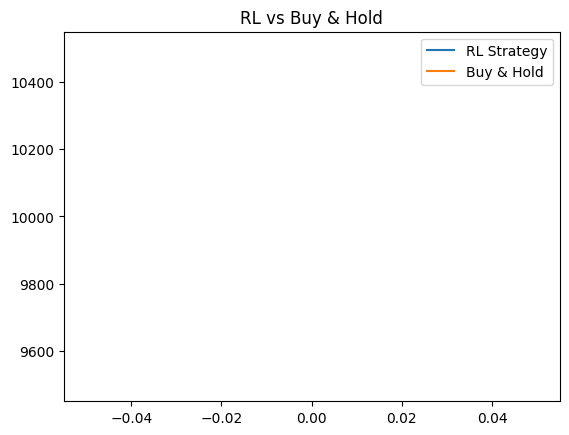

In [7]:
buy_hold = test_df["Close"] / test_df["Close"].iloc[0] * 10000
plt.plot(equity, label="RL Strategy")
plt.plot(buy_hold.values, label="Buy & Hold")
plt.title("RL vs Buy & Hold")
plt.legend()
plt.show()

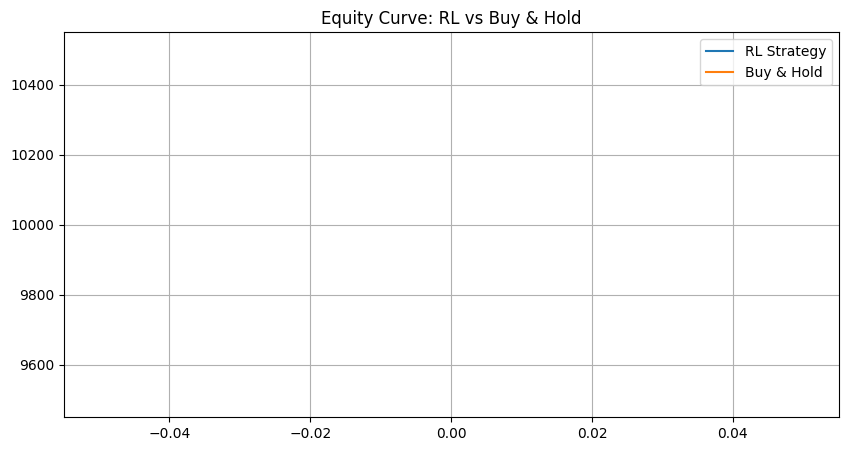

In [8]:
# BENCHMARK (BUY & HOLD)

initial_capital = 10000

buy_hold = test_df["Close"] / test_df["Close"].iloc[0]
buy_hold_equity = buy_hold * initial_capital

# PLOT 

plt.figure(figsize=(10,5))

plt.plot(equity, label="RL Strategy")
plt.plot(buy_hold_equity.values, label="Buy & Hold")

plt.title("Equity Curve: RL vs Buy & Hold")
plt.legend()
plt.grid()

plt.show()

In [9]:
df_trades = pd.DataFrame(test_env.trade_log)

In [10]:
if len(df_trades) > 0:

    equity_series = pd.Series(equity)
    returns = equity_series.pct_change().dropna()

    sharpe = returns.mean() / returns.std() * np.sqrt(365*6)

    cummax = equity_series.cummax()
    drawdown = (equity_series - cummax) / cummax

    wins = df_trades[df_trades["net"] > 0]["net"]
    losses = df_trades[df_trades["net"] <= 0]["net"]

    print("Trades:", len(df_trades))
    print("Win rate:", (df_trades["net"] > 0).mean())
    print("Avg return:", df_trades["net"].mean())
    print("Total return:", (df_trades["net"] + 1).prod() - 1)

    print("Sharpe:", sharpe)
    print("Max Drawdown:", drawdown.min())
    print("Avg win:", wins.mean())
    print("Avg loss:", losses.mean())

else:
    print("⚠️ No trades ejecutados")

Trades: 1
Win rate: 0.0
Avg return: 0.0
Total return: 0
Sharpe: nan
Max Drawdown: 0.0
Avg win: nan
Avg loss: 0.0


In [11]:
pd.Series(actions).value_counts(normalize=True)

NameError: name 'actions' is not defined

In [ ]:
df_trades["net"].hist(bins=50)
plt.title("Distribución de returns por trade")
plt.show()